# CIC3 Attainment vs Rescaled Infectivity

Same structure as the first chart in `replication_seeding_strategies.ipynb` (Figure 3a:
sweep $\lambda$ for several fixed $\lambda_\Delta$), but replaces the SIS steady-state
density $\rho^*$ with the CIC3 global attainment metric ($A_g$ and $A_g^{td}$).

Uses the SI CIC3 model with $C$ competing contagions, each with quota $Q = N/C$
(quotas sum to $N$, no slack). Random seeding only. Multiple independent trials
per ($\lambda$, $\lambda_\Delta$) point to average out stochastic noise.

In [10]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pickle
import hashlib
import os

from scm import RSCGenerator, BAGenerator, SBMGenerator
from scm import MultiRandomSeeding
from scm.cic3_simulator import CIC3Simulator
from scm.analysis import (
    attainment,
    time_discounted_attainment,
    exponential_decay,
)

# --- Cache helpers ---
CACHE_DIR = '../results/cic3_attainment_sweep'

def _param_fingerprint(**kwargs):
    """Deterministic hash of key simulation parameters."""
    raw = str(sorted(kwargs.items()))
    return hashlib.md5(raw.encode()).hexdigest()[:12]

def _cache_path(name):
    return os.path.join(CACHE_DIR, f'{name}.pkl')

def save_cache(name, obj, **fingerprint_kwargs):
    os.makedirs(CACHE_DIR, exist_ok=True)
    fp = _param_fingerprint(**fingerprint_kwargs)
    path = _cache_path(name)
    with open(path, 'wb') as f:
        pickle.dump({'fingerprint': fp, 'data': obj}, f)
    print(f'  Cached {name} -> {path} (fp={fp})')

def load_cache(name, **fingerprint_kwargs):
    """Load cached results if fingerprint matches. Returns None on miss."""
    path = _cache_path(name)
    if not os.path.exists(path):
        return None
    fp = _param_fingerprint(**fingerprint_kwargs)
    with open(path, 'rb') as f:
        blob = pickle.load(f)
    if blob['fingerprint'] != fp:
        print(f'  Cache stale for {name} (disk={blob["fingerprint"]}, current={fp})')
        return None
    print(f'  Loaded {name} from cache (fp={fp})')
    return blob['data']

## Parameters

In [ ]:
# --- Network ---
N = 2000          # keep small-ish for speed with multi-trial CIC3
K_AVG_TARGET = 20
K_D_AVG_TARGET = 6

# --- CIC3 ---
C = 10                          # number of competing contagions
QUOTAS = np.full(C, N // C)     # equal quotas, sum == N (no slack)
SEEDS_PER_CONTAGION = QUOTAS
NUM_SEEDS_PER_CONTAGION = [1] * C
# --- Simulation ---
T_MAX = 500
NUM_TRIALS = 15

# --- Sweep ---
LAMBDA_VALS = np.linspace(0.05, 3.0, 30)
LAMBDA_DELTAS = [0.5, 1.0, 3.0]

# --- Time discount ---
DECAY_RATE = 0.01   # V(t) = exp(-0.01 * t)

# --- Topology seed ---
TOPO_SEED = 2025

V = exponential_decay(DECAY_RATE)

print(f"C = {C}, quotas = {QUOTAS.tolist()}, sum = {QUOTAS.sum()}")
print(f"Seeds per contagion = {NUM_SEEDS_PER_CONTAGION}")
print(f"Trials per point = {NUM_TRIALS}")
print(f"Lambda sweep: {LAMBDA_VALS[0]:.2f} .. {LAMBDA_VALS[-1]:.2f} ({len(LAMBDA_VALS)} pts)")
print(f"Lambda_delta values: {LAMBDA_DELTAS}")

C = 10, quotas = [500, 500, 500, 500, 500, 500, 500, 500, 500, 500], sum = 5000
Seeds per contagion = [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
Trials per point = 15
Lambda sweep: 0.05 .. 3.00 (30 pts)
Lambda_delta values: [0.5, 1.0, 3.0]


## Generate topologies

Same four topologies as the seeding-strategy notebook. Only one graph per
topology (no separate 3a/3b split since there's no bistability panel).

In [12]:
# --- BA defaults ---
BA_M = 5
BA_M_DELTA = 2

# --- SBM defaults (4 equal communities) ---
SBM_K = 10
SBM_INTRA_FRAC = 0.8
SBM_KAVG_EDGE = 14


def make_sbm_block_matrix(N=None, K=SBM_K, intra_frac=SBM_INTRA_FRAC,
                          k_avg_edge=SBM_KAVG_EDGE, values=None):
    if values is not None:
        arr = np.asarray(values, dtype=float)
        if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
            raise ValueError("block_matrix values must be a square list of lists")
        return arr
    p_intra = intra_frac * k_avg_edge * K / N
    p_inter = (1 - intra_frac) * k_avg_edge * K / (N * (K - 1))
    bm = np.full((K, K), p_inter)
    np.fill_diagonal(bm, p_intra)
    return bm


def make_sbm_triangle_kwarg(N=None, K=SBM_K, k_delta_avg=K_D_AVG_TARGET,
                             values=None):
    if values is None:
        p_tri = k_delta_avg * 2 * K**2 / N**2
        return {"triangle_block_probs": [p_tri] * K}
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] != K:
            raise ValueError(f"1D triangle values must have length {K}")
        return {"triangle_block_probs": arr.tolist()}
    if arr.ndim == 3:
        if arr.shape != (K, K, K):
            raise ValueError(
                f"3D triangle values must have shape ({K},{K},{K})"
            )
        return {"triangle_block_tensor": arr}
    raise ValueError("triangle values must be 1D (length K) or 3D ((K,K,K))")


def equal_community_sizes(N, K=SBM_K):
    base = N // K
    sizes = [base] * K
    sizes[-1] += N - base * K
    return sizes


# --- Manual SBM (hub-spoke, scaled to N=500) ---
SBM_MANUAL_K = 5
SBM_MANUAL_SIZES = [200, 150, 100, 45, 5]
SBM_MANUAL_BLOCK = [
    [0.020, 0.003, 0.001, 0.000, 0.3],
    [0.003, 0.025, 0.004, 0.001, 0.3],
    [0.001, 0.004, 0.035, 0.005, 0.3],
    [0.000, 0.001, 0.005, 0.060, 0.3],
    [0.3,   0.3,   0.3,   0.3,   0.3],
]
SBM_MANUAL_TRI = [3e-5, 4e-5, 6e-5, 1e-4, 1e-3]


TOPOLOGY_CONFIGS = [
    {
        "name": "RSC",
        "make": lambda: RSCGenerator(
            k_avg=K_AVG_TARGET, k_delta_avg=K_D_AVG_TARGET, N=N),
    },
    {
        "name": "BA",
        "make": lambda: BAGenerator(
            m=BA_M, m_delta=BA_M_DELTA, N=N),
    },
    {
        "name": "SBM 10 Equal Communities",
        "make": lambda: SBMGenerator(
            community_sizes=equal_community_sizes(N),
            block_matrix=make_sbm_block_matrix(N=N),
            **make_sbm_triangle_kwarg(N=N)),
    },
]

In [13]:
topologies = {}
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    print(f"\n--- Generating {name} ---")
    gen = config["make"]()
    links, triangles = gen.generate(seed=TOPO_SEED)
    topologies[name] = {
        "links": links,
        "triangles": triangles,
        "N": gen.N,
        "k_avg": gen.k_avg,
        "k_d_avg": gen.k_delta_avg,
    }
    print(f"  Realized k_avg = {gen.k_avg:.2f}, k_delta_avg = {gen.k_delta_avg:.2f}")


--- Generating RSC ---
Sampling edges with p_1 = 0.00160417
Edges sampled: 19832/19832
Sampling triangles with p_delta = 0.00000048
Triangles sampled: 10056/10056
Realized k_avg = 19.97, k_delta_avg = 6.03
  Realized k_avg = 19.97, k_delta_avg = 6.03

--- Generating BA ---
BA nodes added: 5000/5000
Realized k_avg = 21.57, k_delta_avg = 6.01
  Realized k_avg = 21.57, k_delta_avg = 6.01

--- Generating SBM 10 Equal Communities ---
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 34878
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 9938
Realized k_avg = 25.47, k_delta_avg = 5.96
  Realized k_avg = 25.47, k_delta_avg = 5.96


## Simulation: sweep lambda at fixed lambda_delta

For each ($\lambda$, $\lambda_\Delta$) point, run `NUM_TRIALS` independent CIC3
simulations. Each trial uses a fresh random seed set. We record $A_g$ and
$A_g^{td}$ (time-discounted) and average across trials.

In [ ]:
def run_attainment_sweep(links, triangles, N_graph, k_avg, k_d_avg,
                         lam_d, num_trials=NUM_TRIALS):
    """Sweep lambda for a fixed lambda_delta.

    Returns (Ag_mean, Ag_td_mean, Ag_std, Ag_td_std) arrays over LAMBDA_VALS.
    """
    # In the CIC3 SI model there is no mu; we still use the rescaled
    # infectivity convention: lambda = beta * k_avg / mu, but since mu
    # just scales beta linearly we can pick mu=1 and set
    #   beta = lambda / k_avg,  beta_delta = lambda_delta / k_d_avg
    # which gives the same transition probabilities as setting mu=0.1
    # with the original rescaling.
    mu = 1.0  # absorbed into rescaling
    beta_d = (lam_d * mu) / k_d_avg

    Ag_all = np.zeros((num_trials, len(LAMBDA_VALS)))
    Ag_td_all = np.zeros((num_trials, len(LAMBDA_VALS)))

    for trial in range(num_trials):
        print(f'Trial {trial+1}/{num_trials}', end='\r')
        for j, lam in enumerate(LAMBDA_VALS):
            beta = (lam * mu) / k_avg

            # All contagions share the same (beta, beta_delta)
            betas = [beta] * C
            beta_deltas = [beta_d] * C

            # Random disjoint seed sets
            seeder = MultiRandomSeeding(
                N_graph, NUM_SEEDS_PER_CONTAGION,
                links=links, triangles=triangles,
            )
            seed_sets = seeder.seed()

            sim = CIC3Simulator(
                links=links,
                triangles=triangles,
                initial_infected_per_contagion=seed_sets,
                betas=betas,
                beta_deltas=beta_deltas,
                quotas=QUOTAS,
                stop_on_all_quotas_met=False,
            )
            sim.run(T_MAX)

            # Compute metrics
            _, Ag = attainment(sim.infected_by, QUOTAS)
            _, Ag_td = time_discounted_attainment(
                sim.infected_by, sim.infection_times, QUOTAS, V
            )

            Ag_all[trial, j] = Ag
            Ag_td_all[trial, j] = Ag_td

    return (
        Ag_all.mean(axis=0),
        Ag_td_all.mean(axis=0),
        Ag_all.std(axis=0),
        Ag_td_all.std(axis=0),
    )


# --- Caching: fingerprint key simulation parameters ---
lambda_sweep_fp = dict(
    N=N, C=C, T_MAX=T_MAX, NUM_TRIALS=NUM_TRIALS,
    DECAY_RATE=DECAY_RATE, TOPO_SEED=TOPO_SEED,
    LAMBDA_VALS=LAMBDA_VALS.tolist(),
    LAMBDA_DELTAS=LAMBDA_DELTAS,
    QUOTAS=QUOTAS.tolist(),
    NUM_SEEDS_PER_CONTAGION=NUM_SEEDS_PER_CONTAGION,
)

all_results = load_cache('lambda_sweep', **lambda_sweep_fp)

if all_results is None:
    all_results = {}

    for config in TOPOLOGY_CONFIGS:
        name = config["name"]
        topo = topologies[name]
        print(f"\n=== Topology: {name} ===")

        topo_results = {}
        for ld in LAMBDA_DELTAS:
            print(f"  lambda_delta = {ld} ...")
            Ag_mean, Ag_td_mean, Ag_std, Ag_td_std = run_attainment_sweep(
                links=topo["links"],
                triangles=topo["triangles"],
                N_graph=topo["N"],
                k_avg=topo["k_avg"],
                k_d_avg=topo["k_d_avg"],
                lam_d=ld,
            )
            topo_results[ld] = {
                "Ag_mean": Ag_mean,
                "Ag_td_mean": Ag_td_mean,
                "Ag_std": Ag_std,
                "Ag_td_std": Ag_td_std,
            }

        all_results[name] = topo_results

    save_cache('lambda_sweep', all_results, **lambda_sweep_fp)
    print("\nDone.")
else:
    print("Skipping lambda sweep (loaded from cache).")


=== Topology: RSC ===
  lambda_delta = 0.5 ...


KeyboardInterrupt: 

## Plot: attainment vs lambda

One figure per topology. Each panel shows three curves (one per $\lambda_\Delta$)
with the solid line = $A_g^{td}$ (time-discounted attainment) and a faint
line behind = $A_g$ (undiscounted). Shaded band = ±1 std across trials.

Saved: ../figures/cic3_attainment_sweep_rsc.png


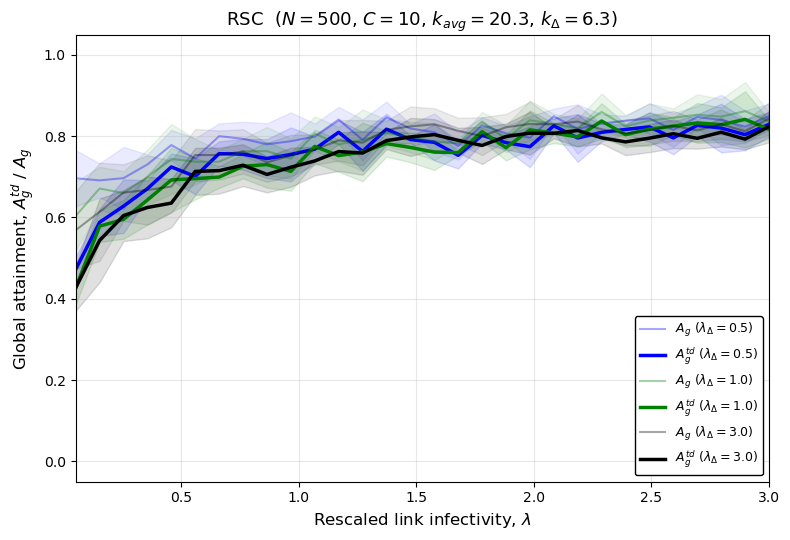

Saved: ../figures/cic3_attainment_sweep_ba.png


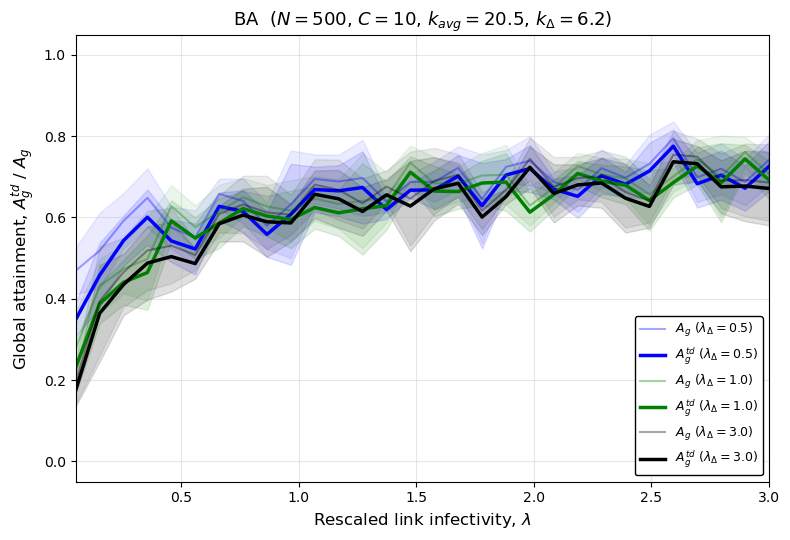

Saved: ../figures/cic3_attainment_sweep_sbm 10 equal communities.png


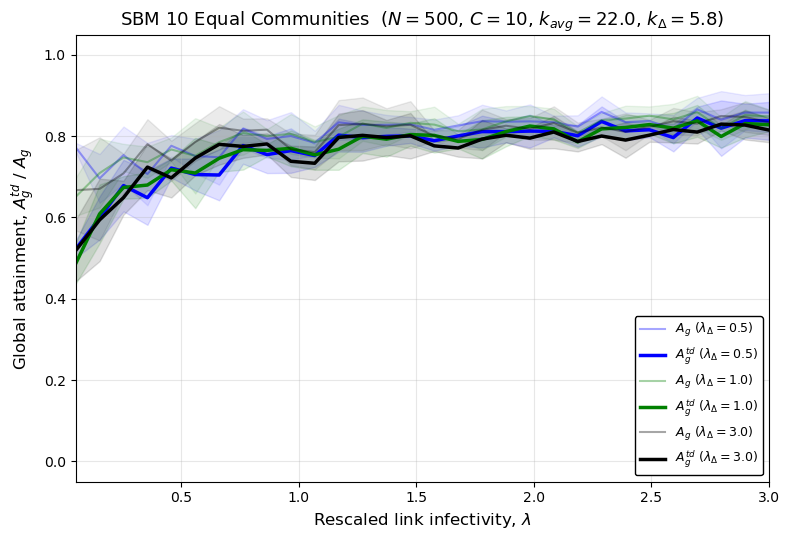

In [ ]:
sim_colors = {0.5: 'blue', 1.0: 'green', 3.0: 'black'}

for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    topo = topologies[name]
    results = all_results[name]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    for ld in LAMBDA_DELTAS:
        res = results[ld]
        color = sim_colors[ld]

        # Faint: undiscounted A_g
        ax.plot(
            LAMBDA_VALS, res["Ag_mean"],
            color=color, lw=1.5, alpha=0.35,
            label=rf'$A_g$ ($\lambda_\Delta={ld}$)',
        )
        ax.fill_between(
            LAMBDA_VALS,
            res["Ag_mean"] - res["Ag_std"],
            res["Ag_mean"] + res["Ag_std"],
            color=color, alpha=0.08,
        )

        # Solid: time-discounted A_g^td
        ax.plot(
            LAMBDA_VALS, res["Ag_td_mean"],
            color=color, lw=2.5,
            label=rf'$A_g^{{td}}$ ($\lambda_\Delta={ld}$)',
        )
        ax.fill_between(
            LAMBDA_VALS,
            res["Ag_td_mean"] - res["Ag_td_std"],
            res["Ag_td_mean"] + res["Ag_td_std"],
            color=color, alpha=0.12,
        )

    ax.set_xlim(LAMBDA_VALS[0], LAMBDA_VALS[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r'Rescaled link infectivity, $\lambda$', fontsize=12)
    ax.set_ylabel(r'Global attainment, $A_g^{td}$ / $A_g$', fontsize=12)
    ax.set_title(
        f'{name}  '
        rf'($N={topo["N"]}$, $C={C}$, '
        rf'$k_{{avg}}={topo["k_avg"]:.1f}$, '
        rf'$k_\Delta={topo["k_d_avg"]:.1f}$)',
        fontsize=13,
    )
    ax.legend(
        loc='lower right', framealpha=1, edgecolor='black', fontsize=9,
    )
    ax.grid(alpha=0.3)

    plt.tight_layout()
    out_path = f'../figures/cic3_attainment_sweep_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

## Complementary sweep: fix lambda, vary lambda_delta

The mirror of the above: fix $\lambda$ at several values and sweep
$\lambda_\Delta$ on the x-axis. This reveals how 2-simplex (group)
reinforcement alone drives attainment when edge infectivity is held
constant.

In [ ]:
# --- Lambda_delta sweep parameters ---
LAMBDA_DELTA_VALS = np.linspace(0.05, 5.0, 30)
FIXED_LAMBDAS = [0.5, 1.0, 2.0]   # edge infectivity held constant

delta_colors = {0.5: 'blue', 1.0: 'green', 2.0: 'black'}

print(f"Lambda_delta sweep: {LAMBDA_DELTA_VALS[0]:.2f} .. {LAMBDA_DELTA_VALS[-1]:.2f} ({len(LAMBDA_DELTA_VALS)} pts)")
print(f"Fixed lambda values: {FIXED_LAMBDAS}")


Lambda_delta sweep: 0.05 .. 5.00 (30 pts)
Fixed lambda values: [0.5, 1.0, 2.0]


In [ ]:
def run_delta_sweep(links, triangles, N_graph, k_avg, k_d_avg,
                    lam, num_trials=NUM_TRIALS):
    """Sweep lambda_delta for a fixed lambda.

    Returns (Ag_mean, Ag_td_mean, Ag_std, Ag_td_std) arrays over LAMBDA_DELTA_VALS.
    """
    mu = 1.0
    beta = (lam * mu) / k_avg

    Ag_all = np.zeros((num_trials, len(LAMBDA_DELTA_VALS)))
    Ag_td_all = np.zeros((num_trials, len(LAMBDA_DELTA_VALS)))

    for trial in range(num_trials):
        for j, lam_d in enumerate(LAMBDA_DELTA_VALS):
            beta_d = (lam_d * mu) / k_d_avg

            betas = [beta] * C
            beta_deltas = [beta_d] * C

            seeder = MultiRandomSeeding(
                N_graph, NUM_SEEDS_PER_CONTAGION,
                links=links, triangles=triangles,
            )
            seed_sets = seeder.seed()

            sim = CIC3Simulator(
                links=links,
                triangles=triangles,
                initial_infected_per_contagion=seed_sets,
                betas=betas,
                beta_deltas=beta_deltas,
                quotas=QUOTAS,
                stop_on_all_quotas_met=False,
            )
            sim.run(T_MAX)

            _, Ag = attainment(sim.infected_by, QUOTAS)
            _, Ag_td = time_discounted_attainment(
                sim.infected_by, sim.infection_times, QUOTAS, V
            )

            Ag_all[trial, j] = Ag
            Ag_td_all[trial, j] = Ag_td

        print(f'    trial {trial+1}/{num_trials} done')

    return (
        Ag_all.mean(axis=0),
        Ag_td_all.mean(axis=0),
        Ag_all.std(axis=0),
        Ag_td_all.std(axis=0),
    )


# --- Caching: fingerprint key simulation parameters ---
delta_sweep_fp = dict(
    N=N, C=C, T_MAX=T_MAX, NUM_TRIALS=NUM_TRIALS,
    DECAY_RATE=DECAY_RATE, TOPO_SEED=TOPO_SEED,
    LAMBDA_DELTA_VALS=LAMBDA_DELTA_VALS.tolist(),
    FIXED_LAMBDAS=FIXED_LAMBDAS,
    QUOTAS=QUOTAS.tolist(),
    NUM_SEEDS_PER_CONTAGION=NUM_SEEDS_PER_CONTAGION,
)

delta_results = load_cache('delta_sweep', **delta_sweep_fp)

if delta_results is None:
    delta_results = {}

    for config in TOPOLOGY_CONFIGS:
        name = config["name"]
        topo = topologies[name]
        print(f"\n=== Topology: {name} ===")

        topo_delta = {}
        for lam in FIXED_LAMBDAS:
            print(f"  lambda = {lam} ...")
            Ag_mean, Ag_td_mean, Ag_std, Ag_td_std = run_delta_sweep(
                links=topo["links"],
                triangles=topo["triangles"],
                N_graph=topo["N"],
                k_avg=topo["k_avg"],
                k_d_avg=topo["k_d_avg"],
                lam=lam,
            )
            topo_delta[lam] = {
                "Ag_mean": Ag_mean,
                "Ag_td_mean": Ag_td_mean,
                "Ag_std": Ag_std,
                "Ag_td_std": Ag_td_std,
            }

        delta_results[name] = topo_delta

    save_cache('delta_sweep', delta_results, **delta_sweep_fp)
    print("\nDone.")
else:
    print("Skipping delta sweep (loaded from cache).")



=== Topology: RSC ===
  lambda = 0.5 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done
  lambda = 1.0 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done
  lambda = 2.0 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done

=== Topology: BA ===
  lambda = 0.5 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done
  lambda = 1.0 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done
  lambda = 2.0 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done

=== Topology: SBM 10 Equal Communities ===
  lambda = 0.5 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done
  lambda = 1.0 ...
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done

Saved: ../figures/cic3_attainment_sweep_delta_rsc.png


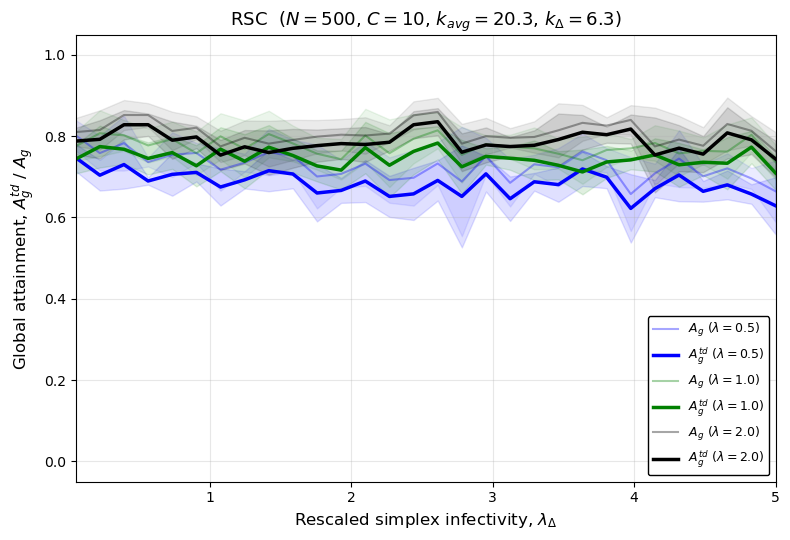

Saved: ../figures/cic3_attainment_sweep_delta_ba.png


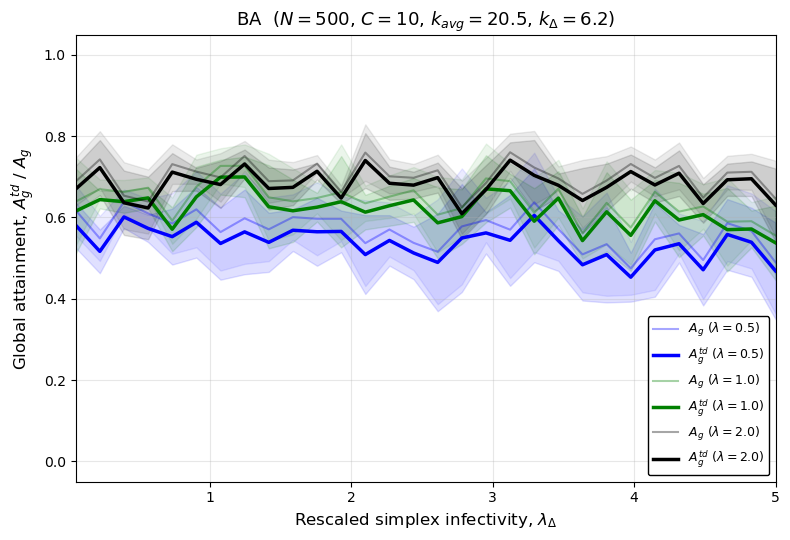

Saved: ../figures/cic3_attainment_sweep_delta_sbm 10 equal communities.png


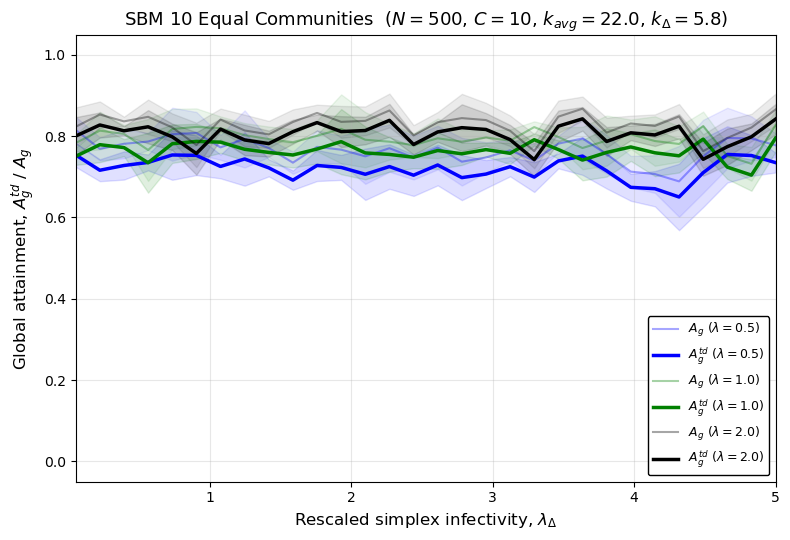

In [ ]:
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    topo = topologies[name]
    results = delta_results[name]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    for lam in FIXED_LAMBDAS:
        res = results[lam]
        color = delta_colors[lam]

        # Faint: undiscounted A_g
        ax.plot(
            LAMBDA_DELTA_VALS, res["Ag_mean"],
            color=color, lw=1.5, alpha=0.35,
            label=rf'$A_g$ ($\lambda={lam}$)',
        )
        ax.fill_between(
            LAMBDA_DELTA_VALS,
            res["Ag_mean"] - res["Ag_std"],
            res["Ag_mean"] + res["Ag_std"],
            color=color, alpha=0.08,
        )

        # Solid: time-discounted A_g^td
        ax.plot(
            LAMBDA_DELTA_VALS, res["Ag_td_mean"],
            color=color, lw=2.5,
            label=rf'$A_g^{{td}}$ ($\lambda={lam}$)',
        )
        ax.fill_between(
            LAMBDA_DELTA_VALS,
            res["Ag_td_mean"] - res["Ag_td_std"],
            res["Ag_td_mean"] + res["Ag_td_std"],
            color=color, alpha=0.12,
        )

    ax.set_xlim(LAMBDA_DELTA_VALS[0], LAMBDA_DELTA_VALS[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r'Rescaled simplex infectivity, $\lambda_\Delta$', fontsize=12)
    ax.set_ylabel(r'Global attainment, $A_g^{td}$ / $A_g$', fontsize=12)
    ax.set_title(
        f'{name}  '
        rf'($N={topo["N"]}$, $C={C}$, '
        rf'$k_{{avg}}={topo["k_avg"]:.1f}$, '
        rf'$k_\Delta={topo["k_d_avg"]:.1f}$)',
        fontsize=13,
    )
    ax.legend(
        loc='lower right', framealpha=1, edgecolor='black', fontsize=9,
    )
    ax.grid(alpha=0.3)

    plt.tight_layout()
    out_path = f'../figures/cic3_attainment_sweep_delta_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

## Aggregated views with regression

Average across the fixed parameter values to get one curve per topology,
then shade the gap between $A_g$ and $A_g^{td}$ to visualize the
time-discount penalty. Add a linear best-fit line and report regression
summary statistics.

In [ ]:
def linreg_summary(x, y):
    """Fit y = a + b*x and return dict with slope, intercept, R^2,
    SE of slope, and t-statistic. No scipy dependency."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    A = np.column_stack([np.ones(n), x])
    coeff, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    y_pred = A @ coeff
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    dof = n - 2
    mse = ss_res / dof if dof > 0 else 0.0
    se_slope = np.sqrt(mse / np.sum((x - x.mean()) ** 2)) if dof > 0 else 0.0
    t_stat = coeff[1] / se_slope if se_slope > 0 else 0.0
    return {
        'intercept': float(coeff[0]),
        'slope': float(coeff[1]),
        'r2': float(r2),
        'se_slope': float(se_slope),
        't_stat': float(t_stat),
        'n': n,
    }

print('linreg_summary ready.')

linreg_summary ready.


AGGREGATED LAMBDA SWEEP  (averaged over lambda_delta values)


<>:42: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:42: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_52749/2160750941.py:42: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  f'{name} (aggregated over $\lambda_\Delta$)  '


Saved: ../figures/cic3_attainment_agg_lambda_rsc.png


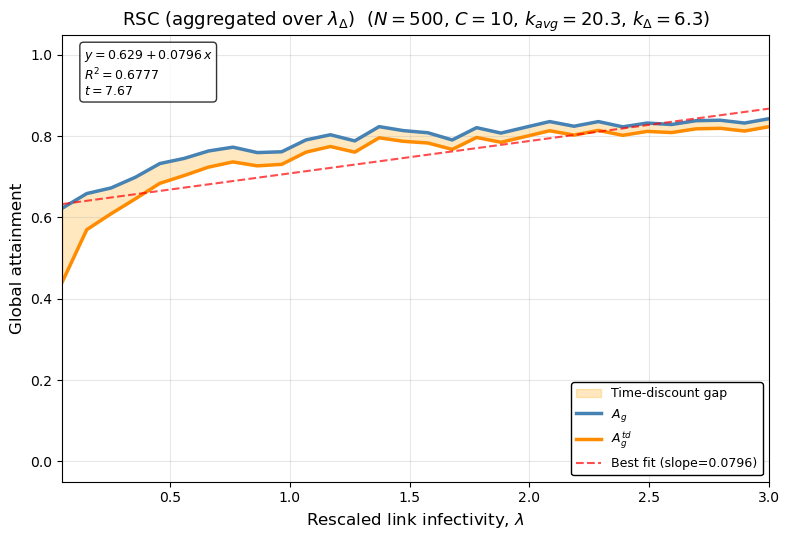

  [RSC] A_g^td ~ lambda
    slope     = 0.079561
    intercept = 0.628993
    R^2       = 0.677738
    SE(slope) = 0.010368
    t(slope)  = 7.6737
    n         = 30

Saved: ../figures/cic3_attainment_agg_lambda_ba.png


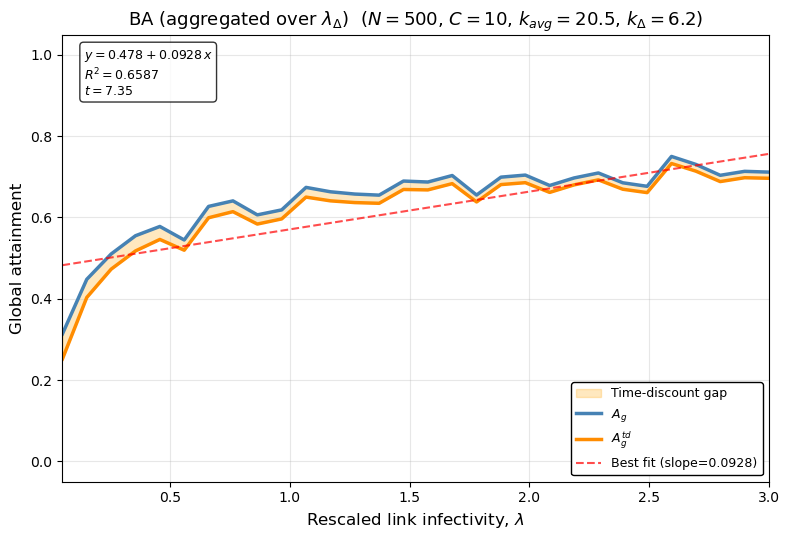

  [BA] A_g^td ~ lambda
    slope     = 0.092834
    intercept = 0.477968
    R^2       = 0.658717
    SE(slope) = 0.012628
    t(slope)  = 7.3514
    n         = 30

Saved: ../figures/cic3_attainment_agg_lambda_sbm 10 equal communities.png


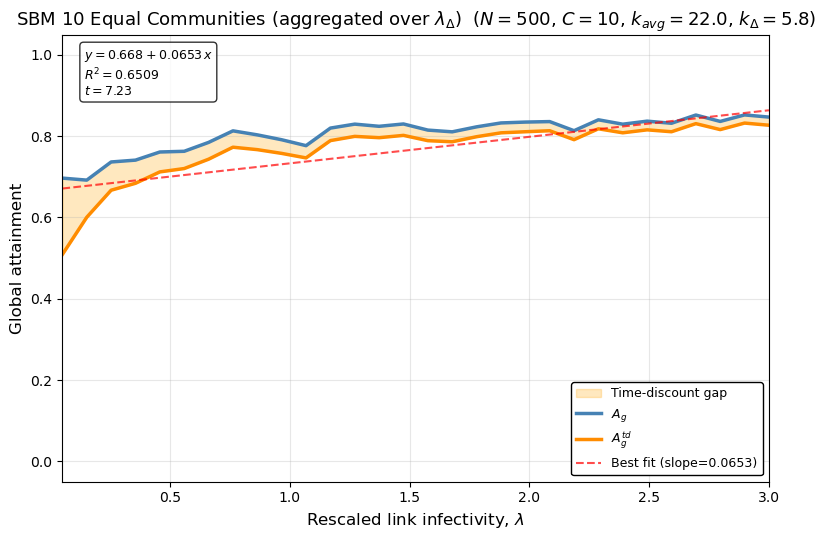

  [SBM 10 Equal Communities] A_g^td ~ lambda
    slope     = 0.065257
    intercept = 0.667939
    R^2       = 0.650930
    SE(slope) = 0.009031
    t(slope)  = 7.2259
    n         = 30



In [ ]:
print('=' * 60)
print('AGGREGATED LAMBDA SWEEP  (averaged over lambda_delta values)')
print('=' * 60)

for config in TOPOLOGY_CONFIGS:
    name = config['name']
    topo = topologies[name]
    results = all_results[name]

    # Stack across lambda_delta values and average
    Ag_stack = np.array([results[ld]['Ag_mean'] for ld in LAMBDA_DELTAS])
    Ag_td_stack = np.array([results[ld]['Ag_td_mean'] for ld in LAMBDA_DELTAS])
    Ag_avg = Ag_stack.mean(axis=0)
    Ag_td_avg = Ag_td_stack.mean(axis=0)

    # Linear regression on A_g^td vs lambda
    reg = linreg_summary(LAMBDA_VALS, Ag_td_avg)
    x_fit = np.array([LAMBDA_VALS[0], LAMBDA_VALS[-1]])
    y_fit = reg['intercept'] + reg['slope'] * x_fit

    fig, ax = plt.subplots(figsize=(8, 5.5))

    # Shaded gap between A_g and A_g^td
    ax.fill_between(
        LAMBDA_VALS, Ag_td_avg, Ag_avg,
        color='orange', alpha=0.25, label='Time-discount gap',
    )
    # A_g line
    ax.plot(LAMBDA_VALS, Ag_avg, color='steelblue', lw=2.5, label=r'$A_g$')
    # A_g^td line
    ax.plot(LAMBDA_VALS, Ag_td_avg, color='darkorange', lw=2.5,
            label=r'$A_g^{td}$')
    # Best-fit line
    ax.plot(x_fit, y_fit, '--', color='red', lw=1.5, alpha=0.7,
            label=f"Best fit (slope={reg['slope']:.4f})")

    ax.set_xlim(LAMBDA_VALS[0], LAMBDA_VALS[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r'Rescaled link infectivity, $\lambda$', fontsize=12)
    ax.set_ylabel(r'Global attainment', fontsize=12)
    ax.set_title(
        f'{name} (aggregated over $\lambda_\Delta$)  '
        rf'($N={topo["N"]}$, $C={C}$, '
        rf'$k_{{avg}}={topo["k_avg"]:.1f}$, '
        rf'$k_\Delta={topo["k_d_avg"]:.1f}$)',
        fontsize=13,
    )
    ax.legend(loc='lower right', framealpha=1, edgecolor='black', fontsize=9)
    ax.grid(alpha=0.3)

    # Annotate regression stats on plot
    stats_text = (
        rf'$y = {reg["intercept"]:.3f} + {reg["slope"]:.4f}\,x$'
        '\n'
        rf'$R^2 = {reg["r2"]:.4f}$'
        '\n'
        rf'$t = {reg["t_stat"]:.2f}$'
    )
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    out_path = f'../figures/cic3_attainment_agg_lambda_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

    # Print regression summary
    print(f'  [{name}] A_g^td ~ lambda')
    print(f'    slope     = {reg["slope"]:.6f}')
    print(f'    intercept = {reg["intercept"]:.6f}')
    print(f'    R^2       = {reg["r2"]:.6f}')
    print(f'    SE(slope) = {reg["se_slope"]:.6f}')
    print(f'    t(slope)  = {reg["t_stat"]:.4f}')
    print(f'    n         = {reg["n"]}')
    print()

AGGREGATED LAMBDA_DELTA SWEEP  (averaged over fixed lambda values)


<>:43: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:43: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_52749/388487720.py:43: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  f'{name} (aggregated over $\lambda$)  '


Saved: ../figures/cic3_attainment_agg_delta_rsc.png


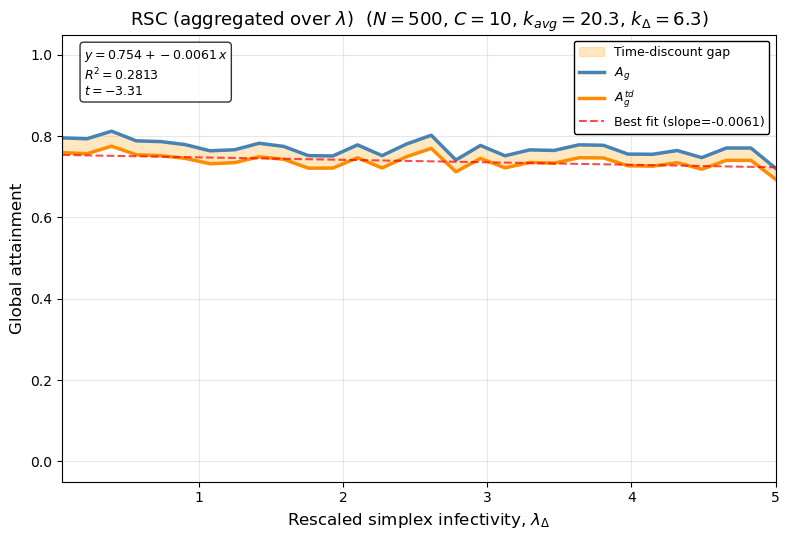

  [RSC] A_g^td ~ lambda_delta
    slope     = -0.006113
    intercept = 0.754033
    R^2       = 0.281296
    SE(slope) = 0.001846
    t(slope)  = -3.3104
    n         = 30

Saved: ../figures/cic3_attainment_agg_delta_ba.png


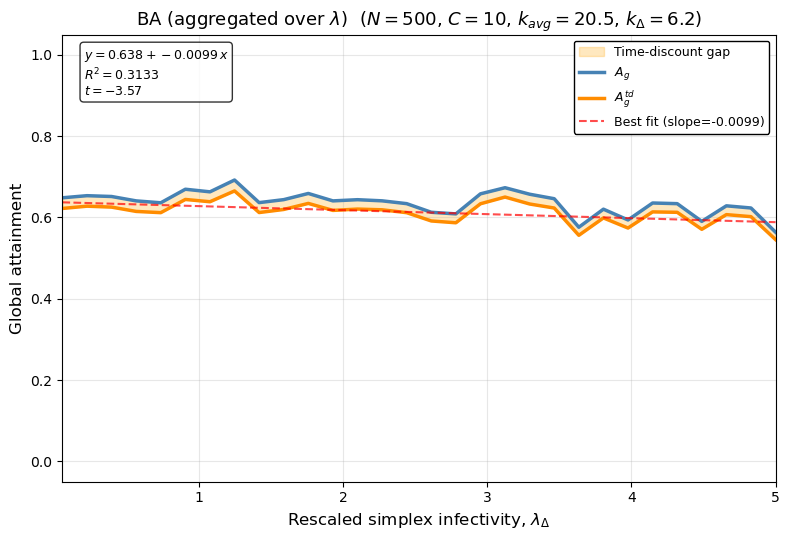

  [BA] A_g^td ~ lambda_delta
    slope     = -0.009867
    intercept = 0.637759
    R^2       = 0.313279
    SE(slope) = 0.002761
    t(slope)  = -3.5740
    n         = 30

Saved: ../figures/cic3_attainment_agg_delta_sbm 10 equal communities.png


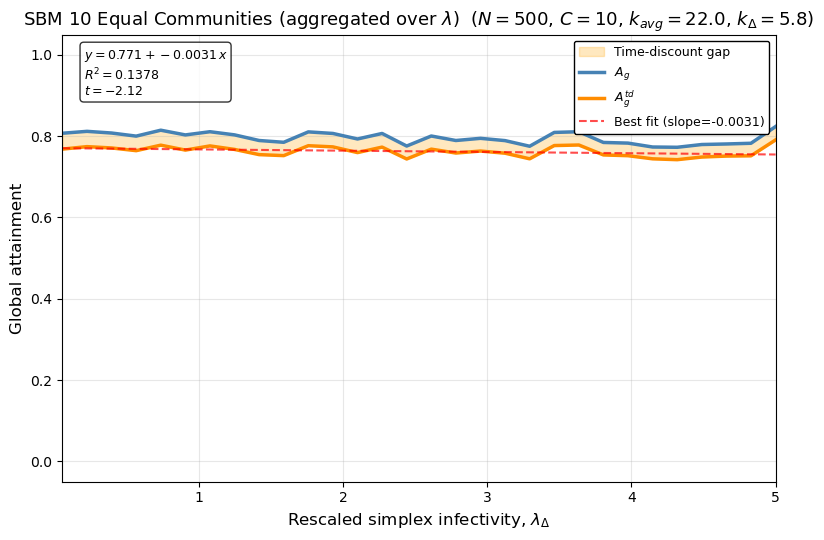

  [SBM 10 Equal Communities] A_g^td ~ lambda_delta
    slope     = -0.003137
    intercept = 0.770594
    R^2       = 0.137772
    SE(slope) = 0.001483
    t(slope)  = -2.1152
    n         = 30



In [ ]:
print('=' * 60)
print('AGGREGATED LAMBDA_DELTA SWEEP  (averaged over fixed lambda values)')
print('=' * 60)

for config in TOPOLOGY_CONFIGS:
    name = config['name']
    topo = topologies[name]
    results = delta_results[name]

    # Stack across fixed lambda values and average
    Ag_stack = np.array([results[lam]['Ag_mean'] for lam in FIXED_LAMBDAS])
    Ag_td_stack = np.array([results[lam]['Ag_td_mean'] for lam in FIXED_LAMBDAS])
    Ag_avg = Ag_stack.mean(axis=0)
    Ag_td_avg = Ag_td_stack.mean(axis=0)

    # Linear regression on A_g^td vs lambda_delta
    reg = linreg_summary(LAMBDA_DELTA_VALS, Ag_td_avg)
    x_fit = np.array([LAMBDA_DELTA_VALS[0], LAMBDA_DELTA_VALS[-1]])
    y_fit = reg['intercept'] + reg['slope'] * x_fit

    fig, ax = plt.subplots(figsize=(8, 5.5))

    # Shaded gap between A_g and A_g^td
    ax.fill_between(
        LAMBDA_DELTA_VALS, Ag_td_avg, Ag_avg,
        color='orange', alpha=0.25, label='Time-discount gap',
    )
    # A_g line
    ax.plot(LAMBDA_DELTA_VALS, Ag_avg, color='steelblue', lw=2.5,
            label=r'$A_g$')
    # A_g^td line
    ax.plot(LAMBDA_DELTA_VALS, Ag_td_avg, color='darkorange', lw=2.5,
            label=r'$A_g^{td}$')
    # Best-fit line
    ax.plot(x_fit, y_fit, '--', color='red', lw=1.5, alpha=0.7,
            label=f"Best fit (slope={reg['slope']:.4f})")

    ax.set_xlim(LAMBDA_DELTA_VALS[0], LAMBDA_DELTA_VALS[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r'Rescaled simplex infectivity, $\lambda_\Delta$', fontsize=12)
    ax.set_ylabel(r'Global attainment', fontsize=12)
    ax.set_title(
        f'{name} (aggregated over $\lambda$)  '
        rf'($N={topo["N"]}$, $C={C}$, '
        rf'$k_{{avg}}={topo["k_avg"]:.1f}$, '
        rf'$k_\Delta={topo["k_d_avg"]:.1f}$)',
        fontsize=13,
    )
    ax.legend(loc='upper right', framealpha=1, edgecolor='black', fontsize=9)
    ax.grid(alpha=0.3)

    # Annotate regression stats on plot
    stats_text = (
        rf'$y = {reg["intercept"]:.3f} + {reg["slope"]:.4f}\,x$'
        '\n'
        rf'$R^2 = {reg["r2"]:.4f}$'
        '\n'
        rf'$t = {reg["t_stat"]:.2f}$'
    )
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    out_path = f'../figures/cic3_attainment_agg_delta_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

    # Print regression summary
    print(f'  [{name}] A_g^td ~ lambda_delta')
    print(f'    slope     = {reg["slope"]:.6f}')
    print(f'    intercept = {reg["intercept"]:.6f}')
    print(f'    R^2       = {reg["r2"]:.6f}')
    print(f'    SE(slope) = {reg["se_slope"]:.6f}')
    print(f'    t(slope)  = {reg["t_stat"]:.4f}')
    print(f'    n         = {reg["n"]}')
    print()

## 2D Metric Heatmaps and Cross-Metric Scatterplots

Sweep both $\lambda$ and $\lambda_\Delta$ over a 2D grid and compute
three metrics at each point: attainment ($A_g^{td}$), deadweight
($D_g$, nodes infected beyond quota), and penetration ($P_g$, average
BFS hop distance from seeds through each contagion's infected subgraph).

Visualized as: (1) deadweight heatmap, (2) penetration heatmap,
(3) attainment vs penetration scatter with best-fit line, and
(4) attainment vs deadweight scatter with best-fit line.

In [ ]:
from scm.analysis import deadweight, penetration

# --- 2D grid parameters ---
HEAT_LAMBDA_VALS = np.linspace(0.1, 3.0, 15)
HEAT_LAMBDA_DELTA_VALS = np.linspace(0.1, 5.0, 15)
HEAT_NUM_TRIALS = 5

def run_2d_sweep(links, triangles, N_graph, k_avg, k_d_avg,
                 num_trials=HEAT_NUM_TRIALS):
    """Sweep (lambda, lambda_delta) on a 2D grid.

    Returns dict with keys:
      Ag_td:  (n_lam, n_lam_d) mean attainment
      Dg:     (n_lam, n_lam_d) mean deadweight
      Pg:     (n_lam, n_lam_d) mean penetration
    """
    mu = 1.0
    n_lam = len(HEAT_LAMBDA_VALS)
    n_ld = len(HEAT_LAMBDA_DELTA_VALS)

    Ag_td_all = np.zeros((num_trials, n_lam, n_ld))
    Dg_all = np.zeros((num_trials, n_lam, n_ld))
    Pg_all = np.zeros((num_trials, n_lam, n_ld))

    for trial in range(num_trials):
        for i, lam in enumerate(HEAT_LAMBDA_VALS):
            beta = (lam * mu) / k_avg
            for j, lam_d in enumerate(HEAT_LAMBDA_DELTA_VALS):
                beta_d = (lam_d * mu) / k_d_avg

                betas = [beta] * C
                beta_deltas = [beta_d] * C

                seeder = MultiRandomSeeding(
                    N_graph, NUM_SEEDS_PER_CONTAGION,
                    links=links, triangles=triangles,
                )
                seed_sets = seeder.seed()

                sim = CIC3Simulator(
                    links=links,
                    triangles=triangles,
                    initial_infected_per_contagion=seed_sets,
                    betas=betas,
                    beta_deltas=beta_deltas,
                    quotas=QUOTAS,
                    stop_on_all_quotas_met=False,
                )
                sim.run(T_MAX)

                _, Ag_td = time_discounted_attainment(
                    sim.infected_by, sim.infection_times, QUOTAS, V
                )
                _, Dg = deadweight(sim.infected_by, QUOTAS)
                _, Pg = penetration(links, sim.infected_by, seed_sets)

                Ag_td_all[trial, i, j] = Ag_td
                Dg_all[trial, i, j] = Dg
                Pg_all[trial, i, j] = Pg

        print(f'    trial {trial+1}/{num_trials} done')

    return {
        'Ag_td': Ag_td_all.mean(axis=0),
        'Dg': Dg_all.mean(axis=0),
        'Pg': Pg_all.mean(axis=0),
        'Ag_td_std': Ag_td_all.std(axis=0),
        'Dg_std': Dg_all.std(axis=0),
        'Pg_std': Pg_all.std(axis=0),
    }


# --- Caching ---
grid_sweep_fp = dict(
    N=N, C=C, T_MAX=T_MAX, HEAT_NUM_TRIALS=HEAT_NUM_TRIALS,
    DECAY_RATE=DECAY_RATE, TOPO_SEED=TOPO_SEED,
    HEAT_LAMBDA_VALS=HEAT_LAMBDA_VALS.tolist(),
    HEAT_LAMBDA_DELTA_VALS=HEAT_LAMBDA_DELTA_VALS.tolist(),
    QUOTAS=QUOTAS.tolist(),
    NUM_SEEDS_PER_CONTAGION=NUM_SEEDS_PER_CONTAGION,
)

grid_results = load_cache('grid_sweep_2d', **grid_sweep_fp)

if grid_results is None:
    grid_results = {}

    for config in TOPOLOGY_CONFIGS:
        name = config['name']
        topo = topologies[name]
        print(f'\n=== Topology: {name} ===')
        res = run_2d_sweep(
            links=topo['links'],
            triangles=topo['triangles'],
            N_graph=topo['N'],
            k_avg=topo['k_avg'],
            k_d_avg=topo['k_d_avg'],
        )
        grid_results[name] = res

    save_cache('grid_sweep_2d', grid_results, **grid_sweep_fp)
    print('\nDone.')
else:
    print('Loaded 2D grid sweep from cache.')


=== Topology: RSC ===
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done

=== Topology: BA ===
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done

=== Topology: SBM 10 Equal Communities ===
    trial 1/5 done
    trial 2/5 done
    trial 3/5 done
    trial 4/5 done
    trial 5/5 done
  Cached grid_sweep_2d -> ../results/cic3_attainment_sweep/grid_sweep_2d.pkl (fp=4019f5b5c4ed)

Done.


DEADWEIGHT HEATMAPS
Saved: ../figures/cic3_deadweight_heatmap_rsc.png


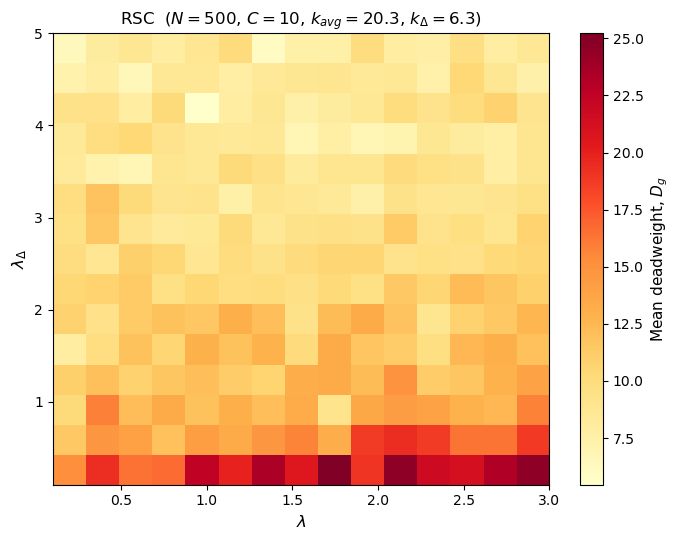

Saved: ../figures/cic3_deadweight_heatmap_ba.png


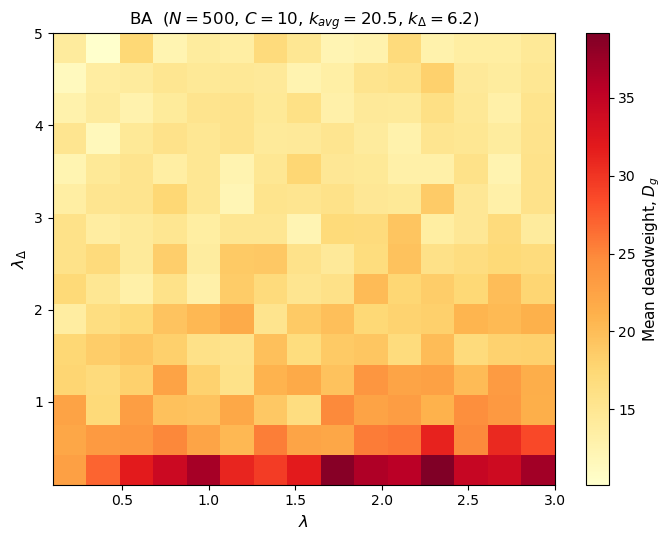

Saved: ../figures/cic3_deadweight_heatmap_sbm 10 equal communities.png


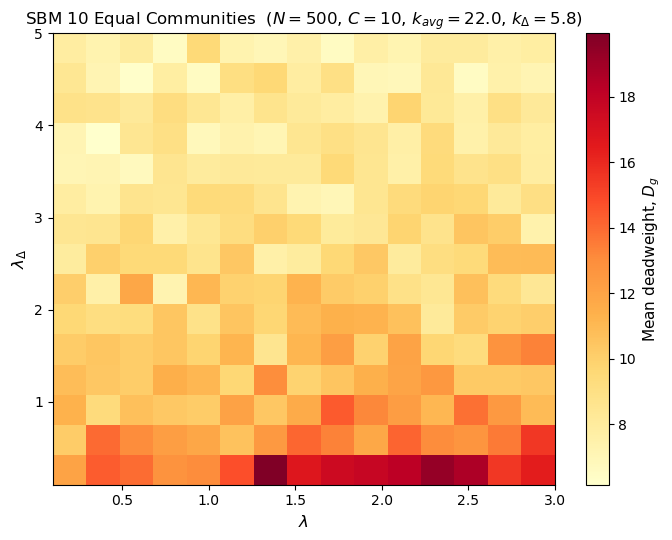

In [ ]:
print('DEADWEIGHT HEATMAPS')
print('=' * 60)

for config in TOPOLOGY_CONFIGS:
    name = config['name']
    topo = topologies[name]
    res = grid_results[name]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(
        res['Dg'],
        origin='lower',
        aspect='auto',
        extent=[
            HEAT_LAMBDA_VALS[0], HEAT_LAMBDA_VALS[-1],
            HEAT_LAMBDA_DELTA_VALS[0], HEAT_LAMBDA_DELTA_VALS[-1],
        ],
        cmap='YlOrRd',
    )
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r'Mean deadweight, $D_g$', fontsize=11)

    ax.set_xlabel(r'$\lambda$', fontsize=12)
    ax.set_ylabel(r'$\lambda_\Delta$', fontsize=12)
    ax.set_title(
        f'{name}  '
        rf'($N={topo["N"]}$, $C={C}$, '
        rf'$k_{{avg}}={topo["k_avg"]:.1f}$, '
        rf'$k_\Delta={topo["k_d_avg"]:.1f}$)',
        fontsize=12,
    )

    plt.tight_layout()
    out_path = f'../figures/cic3_deadweight_heatmap_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

PENETRATION HEATMAPS
Saved: ../figures/cic3_penetration_heatmap_rsc.png


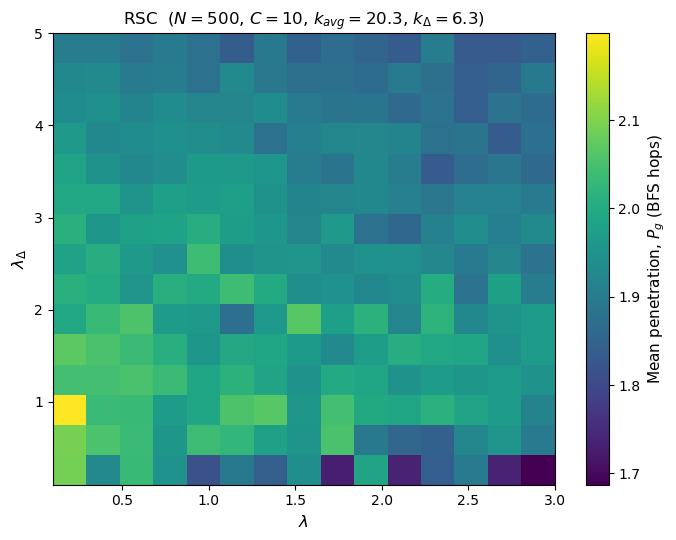

Saved: ../figures/cic3_penetration_heatmap_ba.png


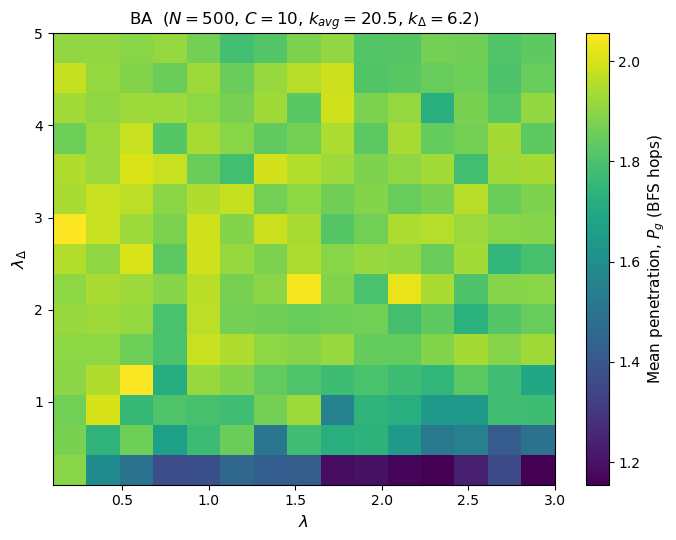

Saved: ../figures/cic3_penetration_heatmap_sbm 10 equal communities.png


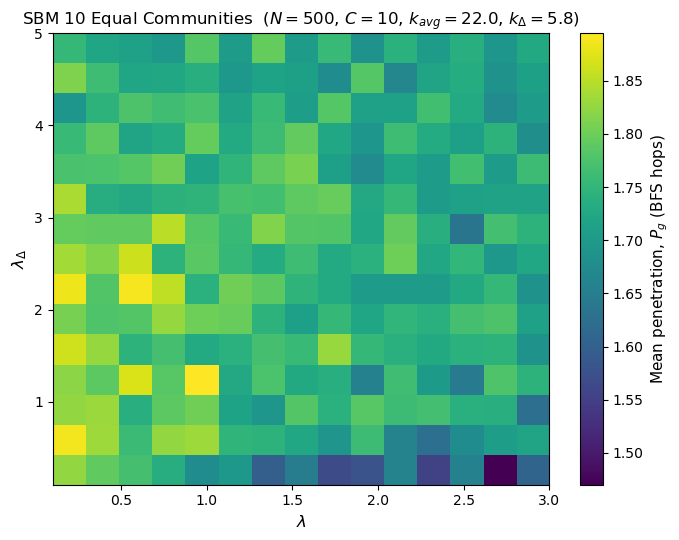

In [ ]:
print('PENETRATION HEATMAPS')
print('=' * 60)

for config in TOPOLOGY_CONFIGS:
    name = config['name']
    topo = topologies[name]
    res = grid_results[name]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(
        res['Pg'],
        origin='lower',
        aspect='auto',
        extent=[
            HEAT_LAMBDA_VALS[0], HEAT_LAMBDA_VALS[-1],
            HEAT_LAMBDA_DELTA_VALS[0], HEAT_LAMBDA_DELTA_VALS[-1],
        ],
        cmap='viridis',
    )
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r'Mean penetration, $P_g$ (BFS hops)', fontsize=11)

    ax.set_xlabel(r'$\lambda$', fontsize=12)
    ax.set_ylabel(r'$\lambda_\Delta$', fontsize=12)
    ax.set_title(
        f'{name}  '
        rf'($N={topo["N"]}$, $C={C}$, '
        rf'$k_{{avg}}={topo["k_avg"]:.1f}$, '
        rf'$k_\Delta={topo["k_d_avg"]:.1f}$)',
        fontsize=12,
    )

    plt.tight_layout()
    out_path = f'../figures/cic3_penetration_heatmap_{name.lower()}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

ATTAINMENT vs PENETRATION
Saved: ../figures/cic3_attainment_vs_penetration.png


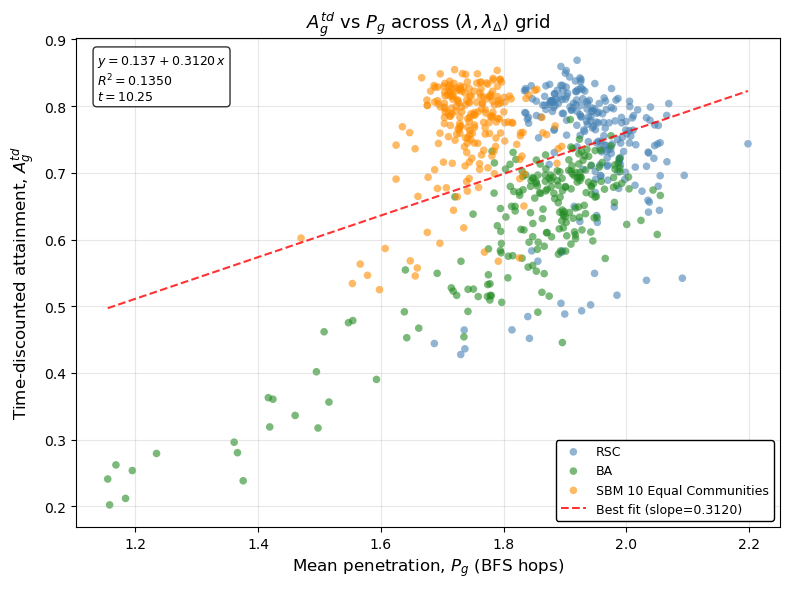

  Global regression: A_g^td ~ P_g
    slope     = 0.311981
    intercept = 0.136787
    R^2       = 0.135034
    SE(slope) = 0.030437
    t(slope)  = 10.2501
    n         = 675


In [ ]:
print('ATTAINMENT vs PENETRATION')
print('=' * 60)

topo_colors = {'RSC': 'steelblue', 'BA': 'forestgreen',
               'SBM 10 Equal Communities': 'darkorange'}

fig, ax = plt.subplots(figsize=(8, 6))

for config in TOPOLOGY_CONFIGS:
    name = config['name']
    res = grid_results[name]
    color = topo_colors.get(name, 'gray')

    # Flatten the 2D grid into 1D arrays of points
    ag_flat = res['Ag_td'].flatten()
    pg_flat = res['Pg'].flatten()
    ax.scatter(pg_flat, ag_flat, alpha=0.6, s=30, color=color,
               label=name, edgecolors='none')

# Global best-fit across all topologies
all_ag = np.concatenate([grid_results[c['name']]['Ag_td'].flatten()
                          for c in TOPOLOGY_CONFIGS])
all_pg = np.concatenate([grid_results[c['name']]['Pg'].flatten()
                         for c in TOPOLOGY_CONFIGS])

reg = linreg_summary(all_pg, all_ag)
x_fit = np.linspace(all_pg.min(), all_pg.max(), 100)
y_fit = reg['intercept'] + reg['slope'] * x_fit
ax.plot(x_fit, y_fit, 'r--', lw=1.5, alpha=0.8,
        label=f"Best fit (slope={reg['slope']:.4f})")

stats_text = (
    rf'$y = {reg["intercept"]:.3f} + {reg["slope"]:.4f}\,x$'
    '\n'
    rf'$R^2 = {reg["r2"]:.4f}$'
    '\n'
    rf'$t = {reg["t_stat"]:.2f}$'
)
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel(r'Mean penetration, $P_g$ (BFS hops)', fontsize=12)
ax.set_ylabel(r'Time-discounted attainment, $A_g^{td}$', fontsize=12)
ax.set_title(
    r'$A_g^{td}$ vs $P_g$ across $(\lambda, \lambda_\Delta)$ grid',
    fontsize=13,
)
ax.legend(loc='lower right', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = '../figures/cic3_attainment_vs_penetration.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

print(f'  Global regression: A_g^td ~ P_g')
print(f'    slope     = {reg["slope"]:.6f}')
print(f'    intercept = {reg["intercept"]:.6f}')
print(f'    R^2       = {reg["r2"]:.6f}')
print(f'    SE(slope) = {reg["se_slope"]:.6f}')
print(f'    t(slope)  = {reg["t_stat"]:.4f}')
print(f'    n         = {reg["n"]}')

ATTAINMENT vs DEADWEIGHT
Saved: ../figures/cic3_attainment_vs_deadweight.png


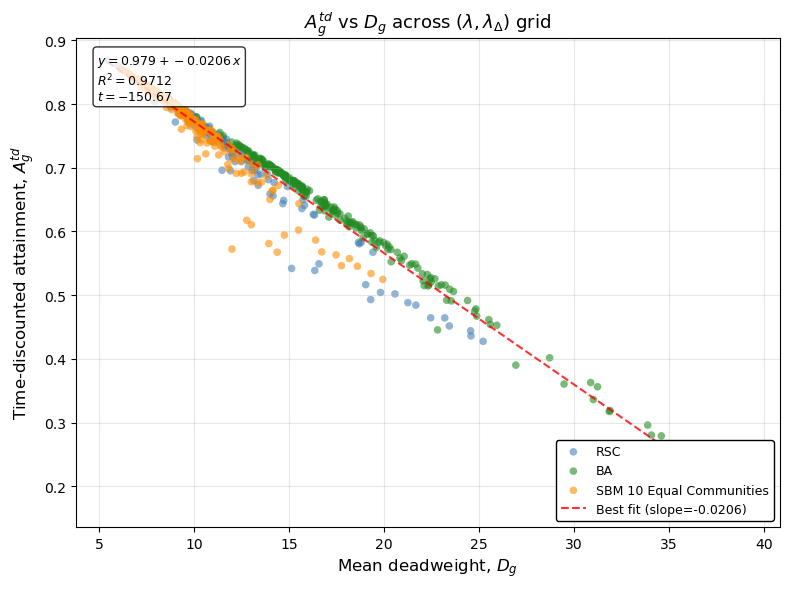

  Global regression: A_g^td ~ D_g
    slope     = -0.020621
    intercept = 0.978592
    R^2       = 0.971209
    SE(slope) = 0.000137
    t(slope)  = -150.6718
    n         = 675


In [ ]:
print('ATTAINMENT vs DEADWEIGHT')
print('=' * 60)

fig, ax = plt.subplots(figsize=(8, 6))

for config in TOPOLOGY_CONFIGS:
    name = config['name']
    res = grid_results[name]
    color = topo_colors.get(name, 'gray')

    ag_flat = res['Ag_td'].flatten()
    dg_flat = res['Dg'].flatten()
    ax.scatter(dg_flat, ag_flat, alpha=0.6, s=30, color=color,
               label=name, edgecolors='none')

# Global best-fit
all_ag = np.concatenate([grid_results[c['name']]['Ag_td'].flatten()
                          for c in TOPOLOGY_CONFIGS])
all_dg = np.concatenate([grid_results[c['name']]['Dg'].flatten()
                         for c in TOPOLOGY_CONFIGS])

reg = linreg_summary(all_dg, all_ag)
x_fit = np.linspace(all_dg.min(), all_dg.max(), 100)
y_fit = reg['intercept'] + reg['slope'] * x_fit
ax.plot(x_fit, y_fit, 'r--', lw=1.5, alpha=0.8,
        label=f"Best fit (slope={reg['slope']:.4f})")

stats_text = (
    rf'$y = {reg["intercept"]:.3f} + {reg["slope"]:.4f}\,x$'
    '\n'
    rf'$R^2 = {reg["r2"]:.4f}$'
    '\n'
    rf'$t = {reg["t_stat"]:.2f}$'
)
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel(r'Mean deadweight, $D_g$', fontsize=12)
ax.set_ylabel(r'Time-discounted attainment, $A_g^{td}$', fontsize=12)
ax.set_title(
    r'$A_g^{td}$ vs $D_g$ across $(\lambda, \lambda_\Delta)$ grid',
    fontsize=13,
)
ax.legend(loc='lower right', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = '../figures/cic3_attainment_vs_deadweight.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

print(f'  Global regression: A_g^td ~ D_g')
print(f'    slope     = {reg["slope"]:.6f}')
print(f'    intercept = {reg["intercept"]:.6f}')
print(f'    R^2       = {reg["r2"]:.6f}')
print(f'    SE(slope) = {reg["se_slope"]:.6f}')
print(f'    t(slope)  = {reg["t_stat"]:.4f}')
print(f'    n         = {reg["n"]}')

## Scatter: $\lambda$ and $\lambda_\Delta$ vs Deadweight & Penetration

From the 2D grid sweep, flatten each metric against each infectivity
parameter separately. Each point is one $(\lambda, \lambda_\Delta)$
grid cell. Colored by topology, with a global best-fit line.

In [ ]:
topo_colors = {'RSC': 'steelblue', 'BA': 'forestgreen',
               'SBM 10 Equal Communities': 'darkorange'}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Build x-arrays by tiling the sweep values across the 2D grid
# grid_results[name]['Dg'] has shape (n_lam, n_lam_d)
# For lambda x-axis: repeat each lambda across all lambda_delta values
# For lambda_delta x-axis: tile lambda_delta values across all lambda values
lam_x = np.repeat(HEAT_LAMBDA_VALS, len(HEAT_LAMBDA_DELTA_VALS))
lam_d_x = np.tile(HEAT_LAMBDA_DELTA_VALS, len(HEAT_LAMBDA_VALS))

plot_specs = [
    (axes[0, 0], lam_d_x, 'Dg', r'$\lambda_\Delta$', r'Deadweight, $D_g$',
     r'$D_g$ vs $\lambda_\Delta$', 'cic3_deadweight_vs_lambda_delta.png'),
    (axes[0, 1], lam_d_x, 'Pg', r'$\lambda_\Delta$', r'Penetration, $P_g$ (BFS hops)',
     r'$P_g$ vs $\lambda_\Delta$', 'cic3_penetration_vs_lambda_delta.png'),
    (axes[1, 0], lam_x, 'Dg', r'$\lambda$', r'Deadweight, $D_g$',
     r'$D_g$ vs $\lambda$', 'cic3_deadweight_vs_lambda.png'),
    (axes[1, 1], lam_x, 'Pg', r'$\lambda$', r'Penetration, $P_g$ (BFS hops)',
     r'$P_g$ vs $\lambda$', 'cic3_penetration_vs_lambda.png'),
]

for ax, x_vals, metric_key, xlabel, ylabel, title, fname in plot_specs:
    all_x = []
    all_y = []

    for config in TOPOLOGY_CONFIGS:
        name = config['name']
        res = grid_results[name]
        color = topo_colors.get(name, 'gray')

        y_flat = res[metric_key].flatten()
        ax.scatter(x_vals, y_flat, alpha=0.6, s=25, color=color,
                   label=name, edgecolors='none')
        all_x.append(x_vals)
        all_y.append(y_flat)

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)

    # Global best-fit
    reg = linreg_summary(all_x, all_y)
    x_fit = np.linspace(all_x.min(), all_x.max(), 100)
    y_fit = reg['intercept'] + reg['slope'] * x_fit
    ax.plot(x_fit, y_fit, 'r--', lw=1.5, alpha=0.8,
            label=f"Best fit (slope={reg['slope']:.4f})")

    stats_text = (
        rf'$y = {reg["intercept"]:.3f} + {reg["slope"]:.4f}\,x$'
        '\n'
        rf'$R^2 = {reg["r2"]:.4f}$'
        '\n'
        rf'$t = {reg["t_stat"]:.2f}$'
    )
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/cic3_lambda_scatter_metrics.png', dpi=300, bbox_inches='tight')
print('Saved: ../figures/cic3_lambda_scatter_metrics.png')
plt.show()

# Also save individual panels
for ax, x_vals, metric_key, xlabel, ylabel, title, fname in plot_specs:
    fig2, ax2 = plt.subplots(figsize=(7, 5.5))
    all_x = []
    all_y = []

    for config in TOPOLOGY_CONFIGS:
        name = config['name']
        res = grid_results[name]
        color = topo_colors.get(name, 'gray')
        y_flat = res[metric_key].flatten()
        ax2.scatter(x_vals, y_flat, alpha=0.6, s=30, color=color,
                    label=name, edgecolors='none')
        all_x.append(x_vals)
        all_y.append(y_flat)

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    reg = linreg_summary(all_x, all_y)
    x_fit = np.linspace(all_x.min(), all_x.max(), 100)
    y_fit = reg['intercept'] + reg['slope'] * x_fit
    ax2.plot(x_fit, y_fit, 'r--', lw=1.5, alpha=0.8,
             label=f"Best fit (slope={reg['slope']:.4f})")

    stats_text = (
        rf'$y = {reg["intercept"]:.3f} + {reg["slope"]:.4f}\,x$'
        '\n'
        rf'$R^2 = {reg["r2"]:.4f}$'
        '\n'
        rf'$t = {reg["t_stat"]:.2f}$'
    )
    ax2.text(0.03, 0.97, stats_text, transform=ax2.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(ylabel, fontsize=12)
    ax2.set_title(title, fontsize=13)
    ax2.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    out_path = f'../figures/{fname}'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')
    plt.show()

    print(f'  Regression: {metric_key} ~ x')
    print(f'    slope     = {reg["slope"]:.6f}')
    print(f'    intercept = {reg["intercept"]:.6f}')
    print(f'    R^2       = {reg["r2"]:.6f}')
    print(f'    SE(slope) = {reg["se_slope"]:.6f}')
    print(f'    t(slope)  = {reg["t_stat"]:.4f}')
    print(f'    n         = {reg["n"]}')
    print()